# Additional Branchpoint Analysis
Finding branch points for:
- Erythroid and Baso
- Mast Erythroid
- Mast Eos
- Baso and Neutrophil

In [1]:
import sys
sys.path.append('/Users/zhaoyimin/Desktop/SCOPE Manuscipt')
import os
import scanpy as sc
from utils import compute_nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
from utils import compute_nn
from branchpoint_localization import trace_to_highest_density_point
import pickle
import random
random.seed(2025)

os.chdir('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance')
data = sc.read_h5ad('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/data_complete_results_clone.h5ad')

with open('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/conformal_result.pkl', 'rb') as file:
    conformal_result = pickle.load(file)

In [2]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
prediction_set = pd.DataFrame(conformal_result['prediction_set'])
#calculate barcode for cells to be recruited 
terminal_state_celltype = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']
day6_terminal_barcode = data[(data.obs['Time_Point'] == '6.0' ) & (data.obs['state_info'].isin(terminal_state_celltype))].obs_names.tolist()
cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()

## 1. Branchpoint: Erythroid and Baso

### 1.1 Find branchpoint

In [4]:
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Erythroid'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Baso'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Erythroid', 'Baso'})
]

# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_ery_baso = prediction_set[combined_condition].index

#subset dataset
data_subset_ery_baso = data[barcode_ery_baso]

#calculate KNN graph
distance, indices = compute_nn(data_subset_ery_baso.obsm['X_pca'], 30)

#do density clustering in new KNN graph
density = data_subset_ery_baso.obs['mellon_log_density'].to_list()

# Step 1: Create label list and index mapping
unique_labels = ['Erythroid', 'Baso']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_ery_baso.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_ery_baso].iloc[:,0]):
    for label in label_set:
        label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])

clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_ery_baso.obsm['X_pca'].shape[0]):
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]

ery_baso_counts = []

for center, points in clusters.items():
    barcode = barcode_ery_baso[points]
    num_ery_baso = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Erythroid', 'Baso'})))
    ery_baso_counts.append((center, num_ery_baso))

# Step 2: Sort clusters by number of Ery+Baso cells (descending)
top_clusters = sorted(ery_baso_counts, key=lambda x: x[1], reverse=True)[:5]

# Step 3: Collect barcodes for top 5 clusters
barcode_branchpoint_top5 = []

for center, _ in top_clusters:
    barcodes = barcode_ery_baso[clusters[center]]
    barcode_branchpoint_top5.append(barcodes)

# Step 5: Save the largest one separately
largest_center = top_clusters[0][0]
barcode_branchpoint_ery_baso = barcode_ery_baso[clusters[largest_center]]

print(f"Found {len(barcode_branchpoint_ery_baso)} cells in Erythroid-Baso branchpoint")

Found 85 cells in Erythroid-Baso branchpoint


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_74642/2148662461.py:65: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_ery_baso = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Erythroid', 'Baso'})))


### 1.2 Plot branchpoint

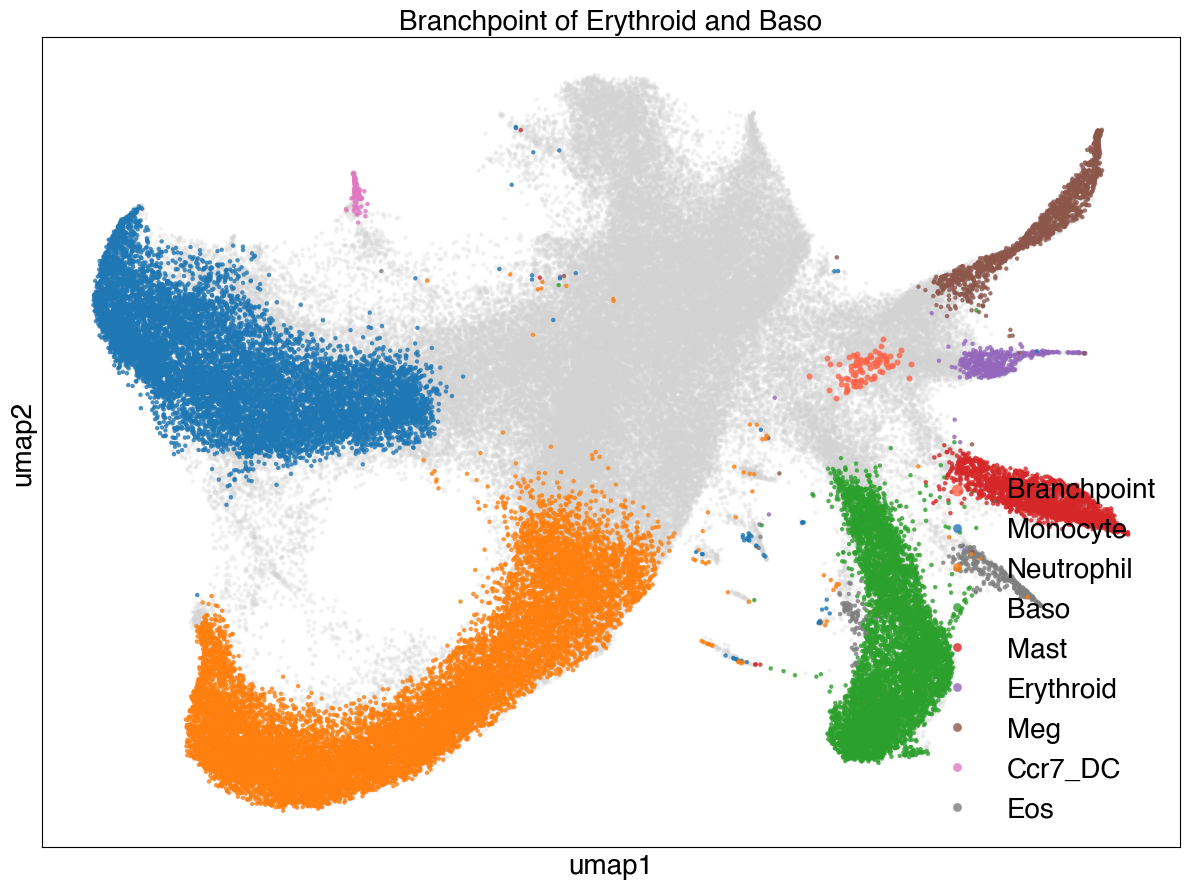

In [8]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['state_info'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint_ery_baso, 'Labels'] = 'Branchpoint'

plt.figure(figsize=(12, 9))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='#FF6347',  s=18, linewidth=0, alpha=0.8, edgecolor='black',  label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0, fontsize=20, frameon=False)
plt.title('Branchpoint of Erythroid and Baso', fontsize=20)
plt.xlabel('umap1', fontsize=20)
plt.ylabel('umap2', fontsize=20)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Appendix/Larry other results/branchpoint_ery_baso.png', dpi=300)
#plt.show()

## 2. Branchpoint: Mast Erythroid

### 2.1 Find branchpoint

In [9]:
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Mast'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Erythroid'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Mast', 'Erythroid'})
]

# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_mast_ery = prediction_set[combined_condition].index

#subset dataset
data_subset_mast_ery = data[barcode_mast_ery]

#calculate KNN graph
distance, indices = compute_nn(data_subset_mast_ery.obsm['X_pca'], 30)

#do density clustering in new KNN graph
density = data_subset_mast_ery.obs['mellon_log_density'].to_list()

# Step 1: Create label list and index mapping
unique_labels = ['Mast', 'Erythroid']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_mast_ery.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_mast_ery].iloc[:,0]):
    for label in label_set:
        label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])

clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_mast_ery.obsm['X_pca'].shape[0]):
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]

mast_ery_counts = []

for center, points in clusters.items():
    barcode = barcode_mast_ery[points]
    num_mast_ery = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Mast', 'Erythroid'})))
    mast_ery_counts.append((center, num_mast_ery))

# Step 2: Sort clusters by number of Mast+Ery cells (descending)
top_clusters = sorted(mast_ery_counts, key=lambda x: x[1], reverse=True)[:5]

# Step 3: Collect barcodes for top 5 clusters
barcode_branchpoint_top5 = []

for center, _ in top_clusters:
    barcodes = barcode_mast_ery[clusters[center]]
    barcode_branchpoint_top5.append(barcodes)

# Step 5: Save the largest one separately
largest_center = top_clusters[0][0]
barcode_branchpoint_mast_ery = barcode_mast_ery[clusters[largest_center]]

print(f"Found {len(barcode_branchpoint_mast_ery)} cells in Mast-Erythroid branchpoint")

Found 92 cells in Mast-Erythroid branchpoint


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_74642/3269397219.py:65: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_mast_ery = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Mast', 'Erythroid'})))


### 2.2 Plot branchpoint

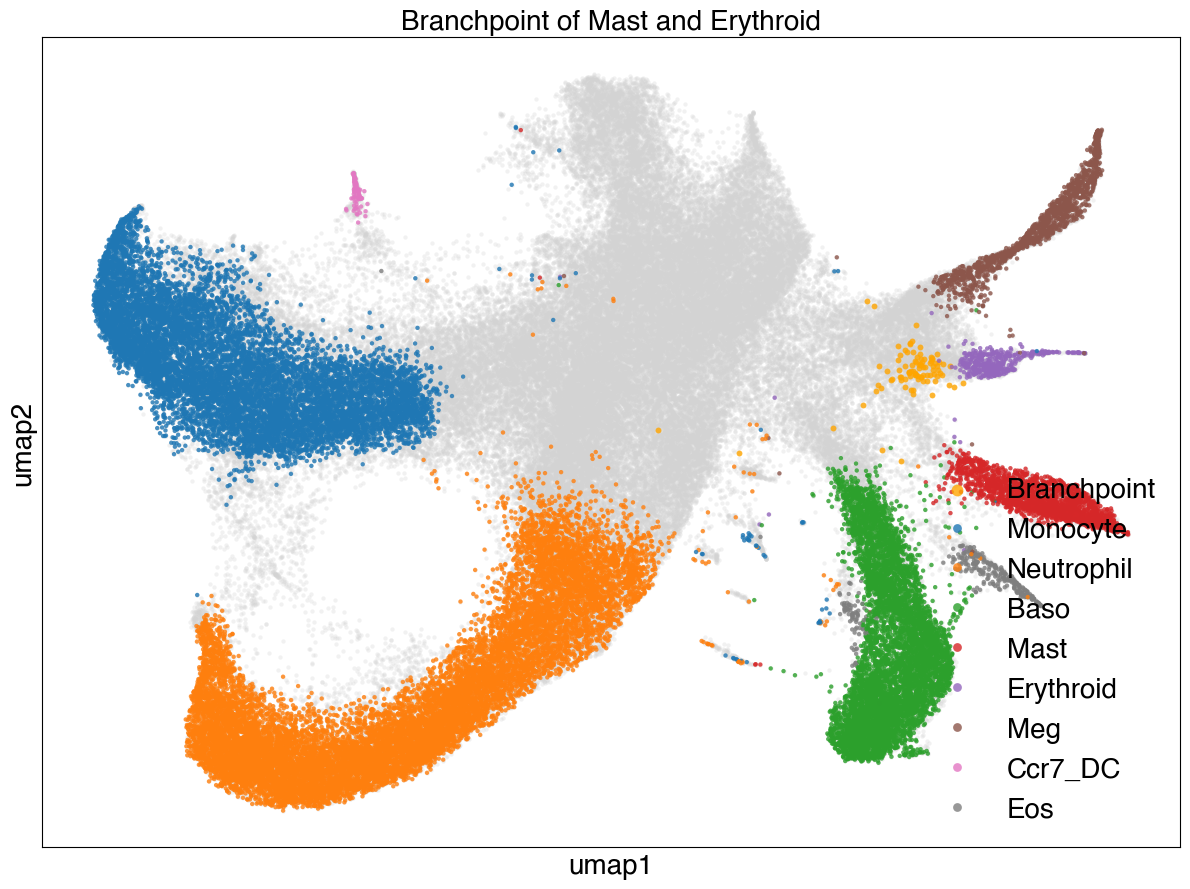

In [12]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['state_info'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint_mast_ery, 'Labels'] = 'Branchpoint'

plt.figure(figsize=(12, 9))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='#FFA500',  s=18, linewidth=0, alpha=0.8, edgecolor='black',  label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0, fontsize=20, frameon=False)
plt.title('Branchpoint of Mast and Erythroid', fontsize=20)
plt.xlabel('umap1', fontsize=20)
plt.ylabel('umap2', fontsize=20)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Appendix/Larry other results/branchpoint_mast_baso.png', dpi=300)
plt.show()

## 3. Branchpoint: Mast Eos

### 3.1 Find branchpoint

In [13]:
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Mast'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Eos'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Mast', 'Eos'})
]

# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_mast_eos = prediction_set[combined_condition].index

#subset dataset
data_subset_mast_eos = data[barcode_mast_eos]

#calculate KNN graph
distance, indices = compute_nn(data_subset_mast_eos.obsm['X_pca'], 30)

#do density clustering in new KNN graph
density = data_subset_mast_eos.obs['mellon_log_density'].to_list()

# Step 1: Create label list and index mapping
unique_labels = ['Mast', 'Eos']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_mast_eos.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_mast_eos].iloc[:,0]):
    for label in label_set:
        label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])

clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_mast_eos.obsm['X_pca'].shape[0]):
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]

mast_eos_counts = []

for center, points in clusters.items():
    barcode = barcode_mast_eos[points]
    num_mast_eos = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Mast', 'Eos'})))
    mast_eos_counts.append((center, num_mast_eos))

# Step 2: Sort clusters by number of Mast+Eos cells (descending)
top_clusters = sorted(mast_eos_counts, key=lambda x: x[1], reverse=True)[:5]

# Step 3: Collect barcodes for top 5 clusters
barcode_branchpoint_top5 = []

for center, _ in top_clusters:
    barcodes = barcode_mast_eos[clusters[center]]
    barcode_branchpoint_top5.append(barcodes)

# Step 5: Save the largest one separately
largest_center = top_clusters[0][0]
barcode_branchpoint_mast_eos = barcode_mast_eos[clusters[largest_center]]

print(f"Found {len(barcode_branchpoint_mast_eos)} cells in Mast-Eos branchpoint")

Found 3 cells in Mast-Eos branchpoint


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_74642/3145930691.py:65: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_mast_eos = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Mast', 'Eos'})))


### 3.2 Plot branchpoint

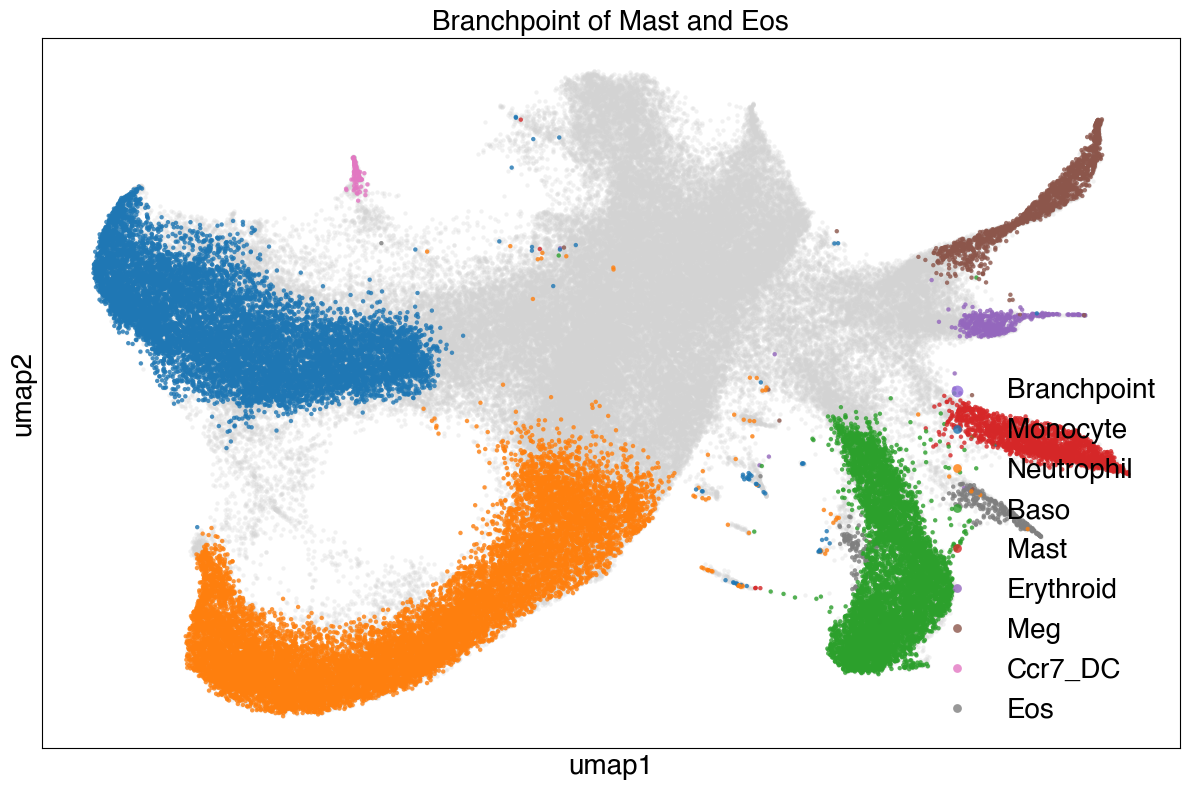

In [14]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['state_info'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint_mast_eos, 'Labels'] = 'Branchpoint'

plt.figure(figsize=(12, 8))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='#9370DB',  s=18, linewidth=0, alpha=0.8, edgecolor='black',  label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0, fontsize=20, frameon=False)
plt.title('Branchpoint of Mast and Eos', fontsize=20)
plt.xlabel('umap1', fontsize=20)
plt.ylabel('umap2', fontsize=20)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
#plt.savefig('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Appendix/Larry other results/branchpoint_mast_eos.png', dpi=300)
plt.show()

## 4. Branchpoint: Baso and Neutrophil

### 4.1 Find branchpoint

In [15]:
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Baso'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Neutrophil'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Baso', 'Neutrophil'})
]

# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_baso_neu = prediction_set[combined_condition].index

#subset dataset
data_subset_baso_neu = data[barcode_baso_neu]

#calculate KNN graph
distance, indices = compute_nn(data_subset_baso_neu.obsm['X_pca'], 30)

#do density clustering in new KNN graph
density = data_subset_baso_neu.obs['mellon_log_density'].to_list()

# Step 1: Create label list and index mapping
unique_labels = ['Baso', 'Neutrophil']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_baso_neu.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_baso_neu].iloc[:,0]):
    for label in label_set:
        label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])

clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_baso_neu.obsm['X_pca'].shape[0]):
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]

baso_neu_counts = []

for center, points in clusters.items():
    barcode = barcode_baso_neu[points]
    num_baso_neu = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Baso', 'Neutrophil'})))
    baso_neu_counts.append((center, num_baso_neu))

# Step 2: Sort clusters by number of Baso+Neu cells (descending)
top_clusters = sorted(baso_neu_counts, key=lambda x: x[1], reverse=True)[:5]

# Step 3: Collect barcodes for top 5 clusters
barcode_branchpoint_top5 = []

for center, _ in top_clusters:
    barcodes = barcode_baso_neu[clusters[center]]
    barcode_branchpoint_top5.append(barcodes)

# Step 5: Save the largest one separately
largest_center = top_clusters[0][0]
barcode_branchpoint_baso_neu = barcode_baso_neu[clusters[largest_center]]

print(f"Found {len(barcode_branchpoint_baso_neu)} cells in Baso-Neutrophil branchpoint")

Found 196 cells in Baso-Neutrophil branchpoint


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_74642/2060519339.py:65: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_baso_neu = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Baso', 'Neutrophil'})))


### 4.2 Plot branchpoint

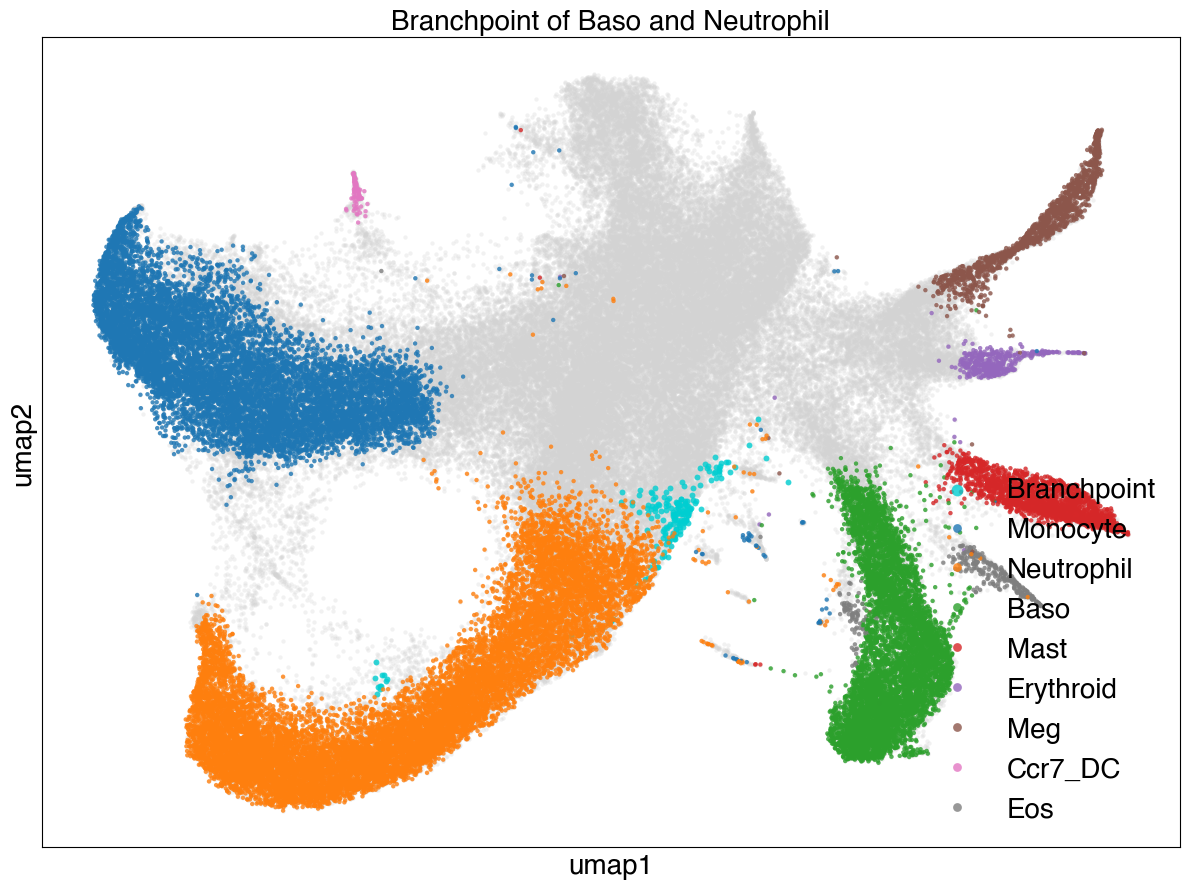

In [16]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['state_info'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint_baso_neu, 'Labels'] = 'Branchpoint'

plt.figure(figsize=(12, 9))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='#00CED1',  s=18, linewidth=0, alpha=0.8, edgecolor='black',  label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0, fontsize=20, frameon=False)
plt.title('Branchpoint of Baso and Neutrophil', fontsize=20)
plt.xlabel('umap1', fontsize=20)
plt.ylabel('umap2', fontsize=20)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

## 5. Combined Plot: All Four New Branchpoints

In [ ]:
plt.figure(figsize=(12, 8))
# Combined plot with all four branchpoints
df_combined = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0], 
    'umap2': data.obsm['X_umap'][:, 1], 
    'Labels': data.obs['state_info'].tolist()
})
df_combined.index = data.obs_names
df_combined.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df_combined.loc[barcode_branchpoint_ery_baso, 'Labels'] = 'Branchpoint_Ery_Baso'
df_combined.loc[barcode_branchpoint_mast_ery, 'Labels'] = 'Branchpoint_Mast_Ery'
df_combined.loc[barcode_branchpoint_mast_eos, 'Labels'] = 'Branchpoint_Mast_Eos'
df_combined.loc[barcode_branchpoint_baso_neu, 'Labels'] = 'Branchpoint_Baso_Neu'

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df_combined,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
)

# Plot Ery-Baso branchpoint
df_ery_baso = df_combined[df_combined['Labels'] == 'Branchpoint_Ery_Baso']
sns.scatterplot(
    x='umap1', y='umap2', data=df_ery_baso,
    color='#FF6347', s=18, linewidth=0, alpha=0.8, edgecolor='black', 
    label='Branchpoint Ery-Baso'
)

# Plot Mast-Ery branchpoint
df_mast_ery = df_combined[df_combined['Labels'] == 'Branchpoint_Mast_Ery']
sns.scatterplot(
    x='umap1', y='umap2', data=df_mast_ery,
    color='#FFA500', s=18, linewidth=0, alpha=0.8, edgecolor='black', 
    label='Branchpoint Mast-Ery'
)

# Plot Mast-Eos branchpoint
df_mast_eos = df_combined[df_combined['Labels'] == 'Branchpoint_Mast_Eos']
sns.scatterplot(
    x='umap1', y='umap2', data=df_mast_eos,
    color='#9370DB', s=18, linewidth=0, alpha=0.8, edgecolor='black', 
    label='Branchpoint Mast-Eos'
)

# Plot Baso-Neu branchpoint
df_baso_neu = df_combined[df_combined['Labels'] == 'Branchpoint_Baso_Neu']
sns.scatterplot(
    x='umap1', y='umap2', data=df_baso_neu,
    color='#00CED1', s=18, linewidth=0, alpha=0.8, edgecolor='black', 
    label='Branchpoint Baso-Neu'
)

# Plot other cell types
df_other = df_combined[~df_combined.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    # Filter out the branchpoints from other cell types to avoid duplication
    df_other = df_other[~df_other['Labels'].str.contains('Branchpoint')]
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower left', markerscale=2.0, fontsize=12, frameon=False)
plt.title('Four New Branchpoints')
plt.xlabel('umap1')
plt.ylabel('umap2')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()